## Import Packages

In [4]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns',100)

## Loading data

In [5]:
train=pd.read_pickle('../data/train_engineered.pkl')


In [6]:
test=pd.read_pickle('../data/train_engineered.pkl')

In [7]:
train.shape

(590540, 453)

In [8]:
test.shape

(590540, 453)

## Baseline Features for Analysis 

In [9]:
baseline_features = [
    "TransactionAmt",
    "TransactionAmt_log",
    "ProductCD",
    "card1",
    "card2",
    "card3",
    "card4",
    "card5",
    "card6",
    "addr1",
    "addr2",
    "dist1",
    "dist2",
    "P_emaildomain_group",
    "R_emaildomain_group",
    "P_emaildomain_suffix",
    "R_emaildomain_suffix",
    "match_email",
    "browser_group",
    "os_group",
    "DeviceType",
    "C1",
    "C2",
    "C13",
    "D1",
    "D10",
    "D15",
    "TransactionAmt_to_mean_card1",
    "TransactionAmt_to_std_card1",
    "TransactionAmt_to_mean_card4",
    "TransactionAmt_to_std_card4"
]

## Dependent & Independent Variables

In [10]:
X = train[baseline_features].copy()
y = train['isFraud'].copy()

## Identify Categorical & Numerical Variables

In [11]:
categorical_cols = X.select_dtypes(include='object').columns.tolist()
numerical_cols = X.select_dtypes(exclude='object').columns.tolist()

print(f'Categorical Columns {categorical_cols}')
print(f'Numerical Columns {numerical_cols}')

Categorical Columns ['ProductCD', 'card4', 'card6', 'P_emaildomain_group', 'R_emaildomain_group', 'P_emaildomain_suffix', 'R_emaildomain_suffix', 'browser_group', 'os_group', 'DeviceType']
Numerical Columns ['TransactionAmt', 'TransactionAmt_log', 'card1', 'card2', 'card3', 'card5', 'addr1', 'addr2', 'dist1', 'dist2', 'match_email', 'C1', 'C2', 'C13', 'D1', 'D10', 'D15', 'TransactionAmt_to_mean_card1', 'TransactionAmt_to_std_card1', 'TransactionAmt_to_mean_card4', 'TransactionAmt_to_std_card4']


## Encoding Categorical Columns

In [12]:
for col in categorical_cols:
    le=LabelEncoder()
    X[col]=X[col].astype(str)
    X[col]=le.fit_transform(X[col])

## Handling Missing Values

In [13]:
impute=SimpleImputer(strategy='median')
X_imputed=pd.DataFrame(impute.fit_transform(X),columns=X.columns)

## Train Test Split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X_imputed,y,test_size=0.2,random_state=42,stratify=y)

In [15]:
print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')

X_train shape: (472432, 31)
X_test shape: (118108, 31)


In [16]:
print(f'Training target distribution {y_train.value_counts(normalize=True)*100}')
print(f'Testing target distribution {y_test.value_counts(normalize=True)*100}')

Training target distribution isFraud
0    96.501084
1     3.498916
Name: proportion, dtype: float64
Testing target distribution isFraud
0    96.50066
1     3.49934
Name: proportion, dtype: float64


A stratified train-test split was used because the target variable is highly imbalanced. Stratification ensures that the fraud and non-fraud proportions remain similar in both training and testing sets.

### Feature Scaling

In [17]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.fit_transform(X_test)

Feature scaling was applied for Logistic Regression because it is sensitive to differences in feature scale. Tree-based models such as Decision Tree and Random Forest do not require scaling, but the scaled data will be used for Logistic Regression.

## Evaluation Functions

In [18]:
model_results = []

In [19]:
def evaluate_model(model_name, model, X_train_data, X_test_data, y_train, y_test):
    y_pred = model.predict(X_test_data)

    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test_data)[:,1]
        roc_auc= roc_auc_score(y_test, y_pred)
    else:
        roc_auc=np.nan


    accuracy=accuracy_score(y_test, y_pred)
    precision=precision_score(y_test, y_pred)
    recall=recall_score(y_test, y_pred)
    f1=f1_score(y_test, y_pred)
    cr=classification_report(y_test, y_pred)

    print(f'Model: {model_name}')
    print('=' * 40)
    print(f'Accuracy: {accuracy}')
    print(f'Precision: {precision}')
    print(f'Recall: {recall}')
    print(f'F1 Score: {f1} ')
    print(f'\n Classification Report:\n {cr}')

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()

    model_results.append({'Model':model_name, 'Accuracy':accuracy, 'Precision':precision, 'Recall':recall, 'ROC-AUC':roc_auc})
    
    

# Base Models

## Logistic Regression 

In [20]:
lr_model = LogisticRegression(
    max_iter = 1000,
    class_weight = 'balanced',
    random_state = 42
)
lr_model.fit(X_train_scaled,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


Model: Logistic Regression
Accuracy: 0.7430064009211907
Precision: 0.08486383787207093
Recall: 0.6484393902734091
F1 Score: 0.15008540307451068 

 Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.75      0.85    113975
           1       0.08      0.65      0.15      4133

    accuracy                           0.74    118108
   macro avg       0.53      0.70      0.50    118108
weighted avg       0.95      0.74      0.82    118108



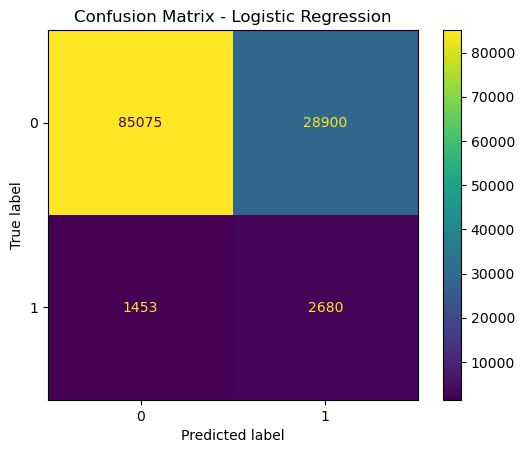

In [21]:
evaluate_model('Logistic Regression',lr_model, X_train_scaled, X_test_scaled, y_train,  y_test)

Logistic Regression was used as the first baseline model because it is simple, interpretable, and commonly used for binary classification problems. Since the fraud class is highly underrepresented, class_weight='balanced' was used to reduce bias toward the majority class.

## Decision Tree

In [22]:
dt_model = DecisionTreeClassifier(max_depth=10, class_weight="balanced",random_state=42)
dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


Model: Decision Tree
Accuracy: 0.8289362278592475
Precision: 0.1397444519166106
Recall: 0.7541737236873941
F1 Score: 0.2357969589227627 

 Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.83      0.90    113975
           1       0.14      0.75      0.24      4133

    accuracy                           0.83    118108
   macro avg       0.56      0.79      0.57    118108
weighted avg       0.96      0.83      0.88    118108



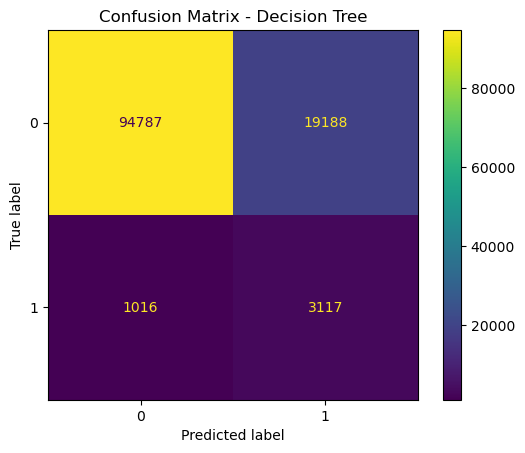

In [23]:
evaluate_model("Decision Tree", dt_model, X_train, X_test, y_train, y_test)

Decision Tree was used to capture non-linear relationships between features and fraud. A maximum depth was set to reduce overfitting.

## Random Forest

In [25]:
rf_model = RandomForestClassifier(n_estimators=100, max_depth=12, class_weight='balanced', n_jobs=-1, random_state=42)
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,12
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Model: Random Forest
Accuracy: 0.9293189284383785
Precision: 0.28969164754016563
Recall: 0.7023953544640696
F1 Score: 0.4102020630210541 

 Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.94      0.96    113975
           1       0.29      0.70      0.41      4133

    accuracy                           0.93    118108
   macro avg       0.64      0.82      0.69    118108
weighted avg       0.96      0.93      0.94    118108



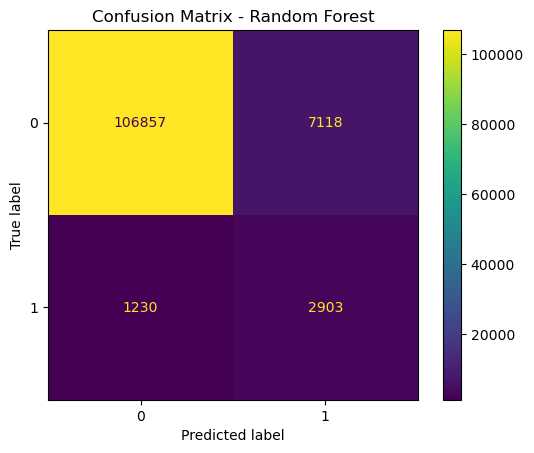

In [26]:
evaluate_model("Random Forest", rf_model, X_train, X_test, y_train, y_test)

Random Forest combines multiple decision trees and usually performs better than a single Decision Tree by reducing overfitting and improving generalization.

In [30]:
model_results

[{'Model': 'Logistic Regression',
  'Accuracy': 0.7430064009211907,
  'Precision': 0.08486383787207093,
  'Recall': 0.6484393902734091,
  'ROC-AUC': 0.6974375060601528},
 {'Model': 'Decision Tree',
  'Accuracy': 0.8289362278592475,
  'Precision': 0.1397444519166106,
  'Recall': 0.7541737236873941,
  'ROC-AUC': 0.7929105073799989},
 {'Model': 'Random Forest',
  'Accuracy': 0.9293189284383785,
  'Precision': 0.28969164754016563,
  'Recall': 0.7023953544640696,
  'ROC-AUC': 0.8199715311473672}]

In [31]:
type(model_results)

list

In [36]:
results_df=pd.DataFrame(model_results)
results_df

,Model,Accuracy,Precision,Recall,ROC-AUC
0,Logistic Regression,0.743006,0.084864,0.648439,0.697438
1,Decision Tree,0.828936,0.139744,0.754174,0.792911
2,Random Forest,0.929319,0.289692,0.702395,0.819972


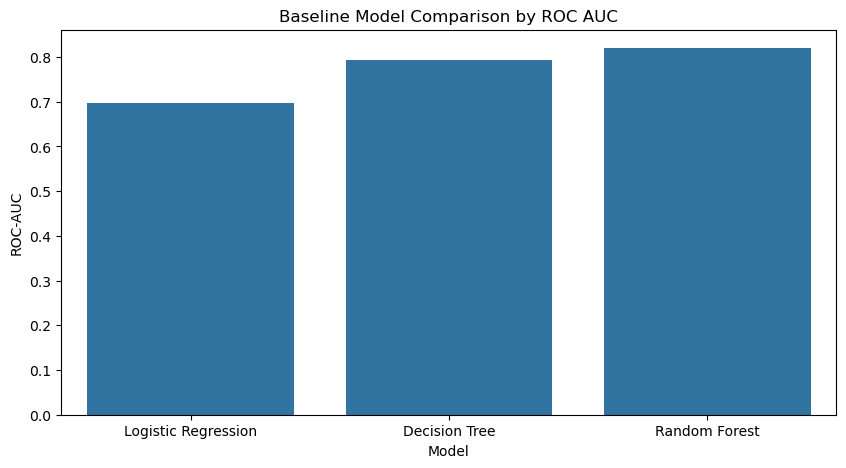

In [42]:
plt.figure(figsize=(10,5))
sns.barplot(data=results_df, x='Model', y='ROC-AUC')
plt.title("Baseline Model Comparison by ROC AUC")
plt.show()

## Random Forest Feature Importance

In [51]:
feature_importance = pd.DataFrame({'Feature':X_train.columns, 'Importance':rf_model.feature_importances_}).sort_values(by='Importance', ascending=False)

In [52]:
feature_importance.head(20)

,Feature,Importance
21,C1,0.091561
23,C13,0.091180
22,C2,0.069109
24,D1,0.057430
16,R_emaildomain_suffix,0.054226
14,R_emaildomain_group,0.053441
26,D15,0.049777
5,card3,0.046091
2,ProductCD,0.043288
25,D10,0.038846


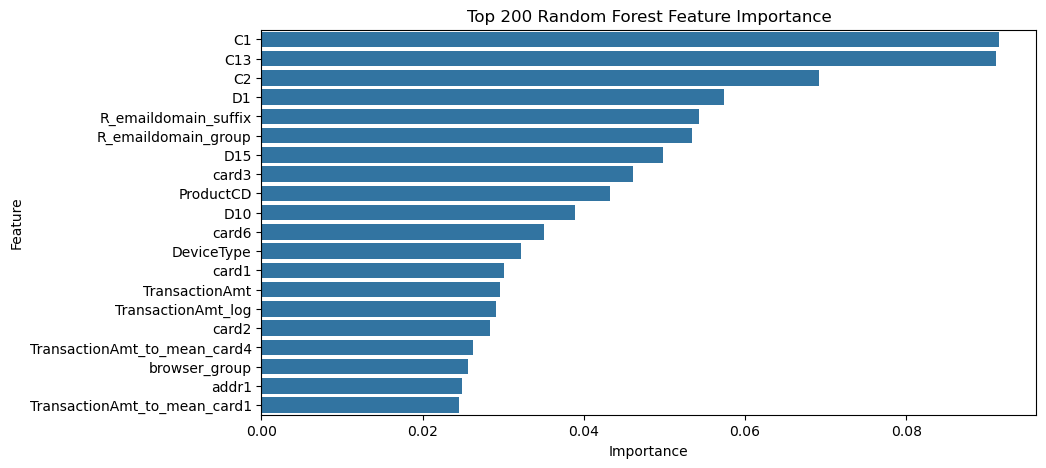

In [55]:
plt.figure(figsize=(10,5))
sns.barplot(data=feature_importance.head(20), y='Feature',x="Importance")
plt.title('Top 200 Random Forest Feature Importance')
plt.show()